In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('../data/mexico-real-estate.csv')
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
df.head()

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.56,-99.23,150.00,"67,965.56"
1,house,Nuevo León,25.69,-100.20,186.00,"63,223.78"
2,apartment,Guerrero,16.77,-99.76,82.00,"84,298.37"
3,apartment,Guerrero,16.83,-99.91,150.00,"94,308.80"
4,house,Yucatán,21.05,-89.54,205.00,"105,191.37"


In [23]:
df['property_type'].value_counts(normalize=True) * 100

property_type
house       76.56
apartment   23.44
Name: proportion, dtype: float64

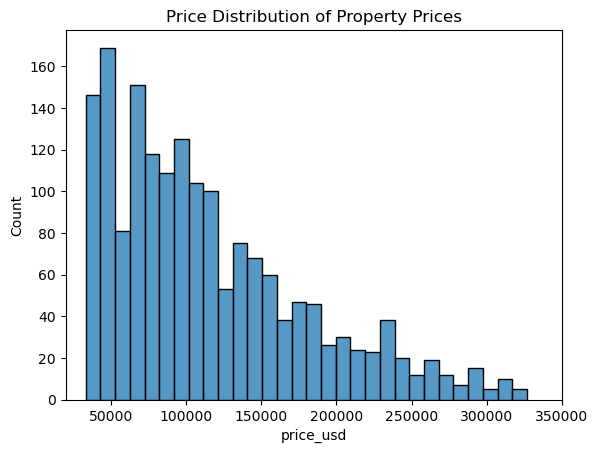

In [27]:
sns.histplot(
    df['price_usd'],
    bins=30
)

plt.xlim(20000, 350000)
plt.title('Price Distribution of Property Prices');

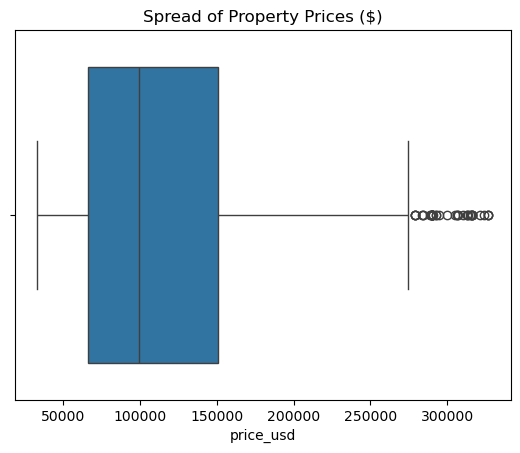

In [33]:
sns.boxplot(
    x=df['price_usd']
)

plt.title('Spread of Property Prices ($)');

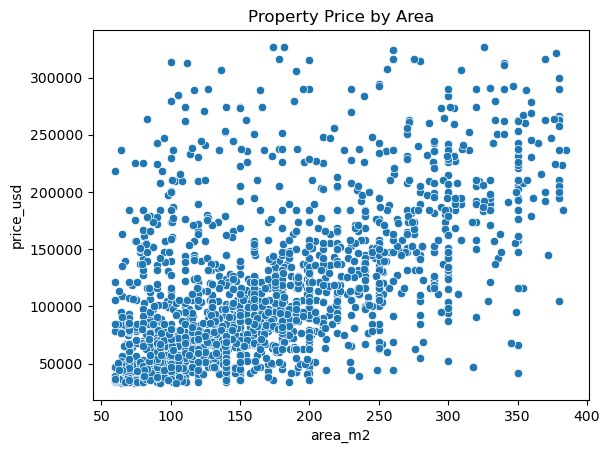

In [37]:
sns.scatterplot(
    df,
    x='area_m2',
    y='price_usd'
)

plt.title('Property Price by Area');

In [40]:
df['price_usd'].corr(df['area_m2']) * 100

np.float64(58.55182454266905)

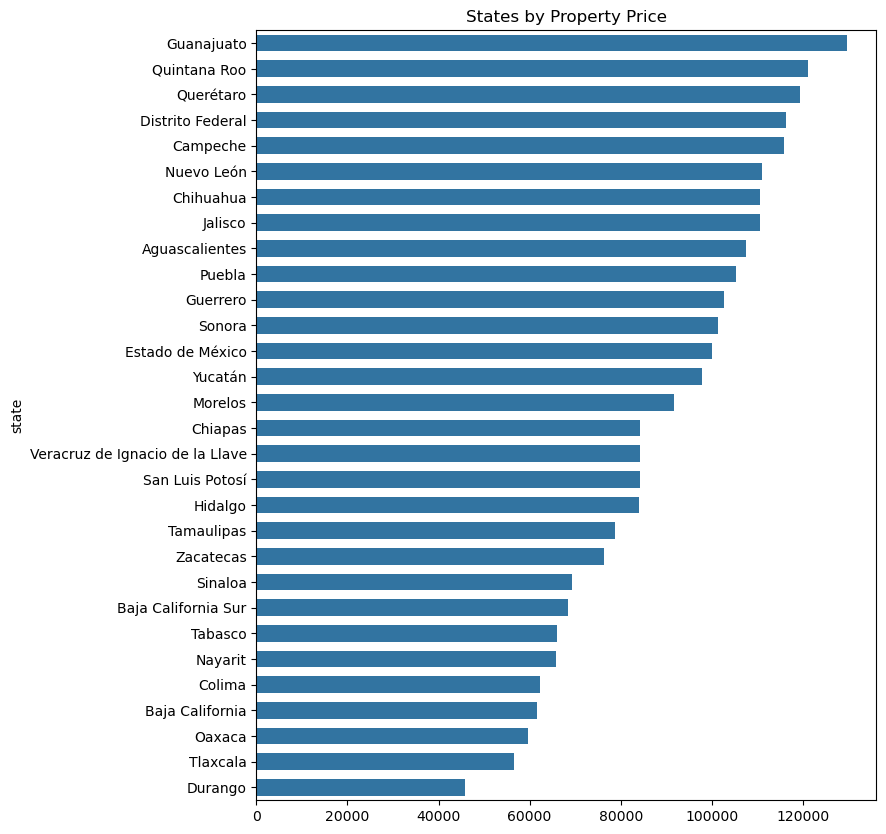

In [98]:
fig, ax = plt.subplots(figsize=(8, 10))

price_by_state = df.groupby('state')['price_usd'].median().sort_values(ascending=False)

sns.barplot(
    x=price_by_state.values,
    y=price_by_state.index,
    width=0.65,
    ax=ax
)

ax.set_title('States by Property Price');

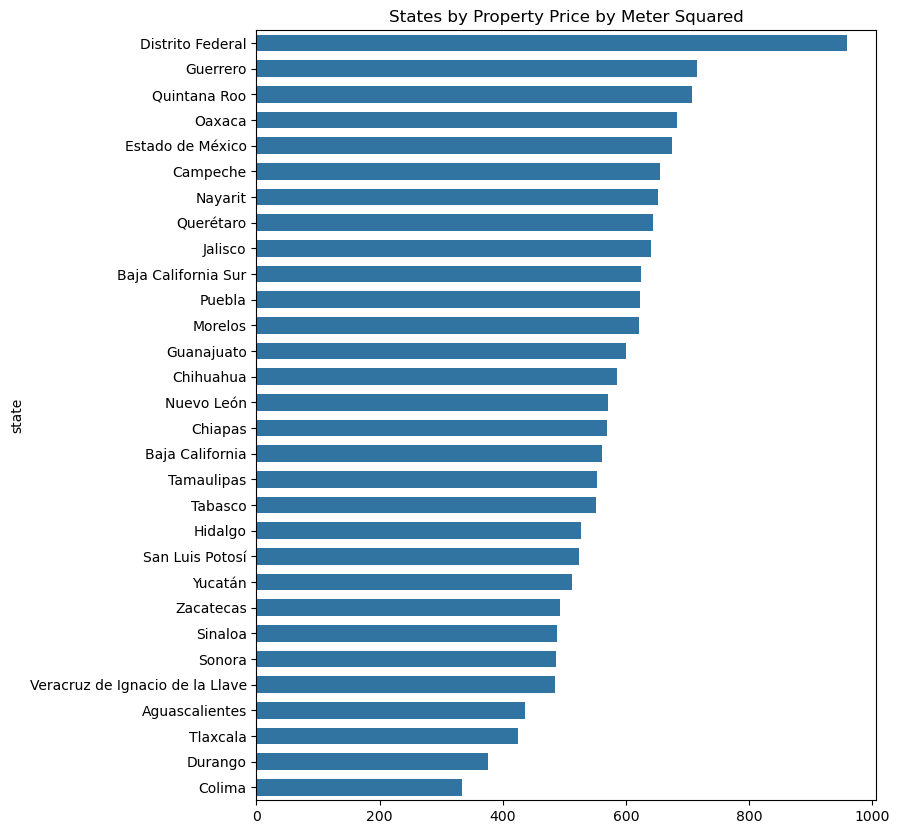

In [99]:
df['price_per_m2'] = df['price_usd'] / df['area_m2']

price_m2_by_state =  df.groupby('state')['price_per_m2'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 10))

sns.barplot(
    x=price_m2_by_state.values,
    y=price_m2_by_state.index,
    width=0.65,
    ax=ax
)

ax.set_title('States by Property Price by Meter Squared');

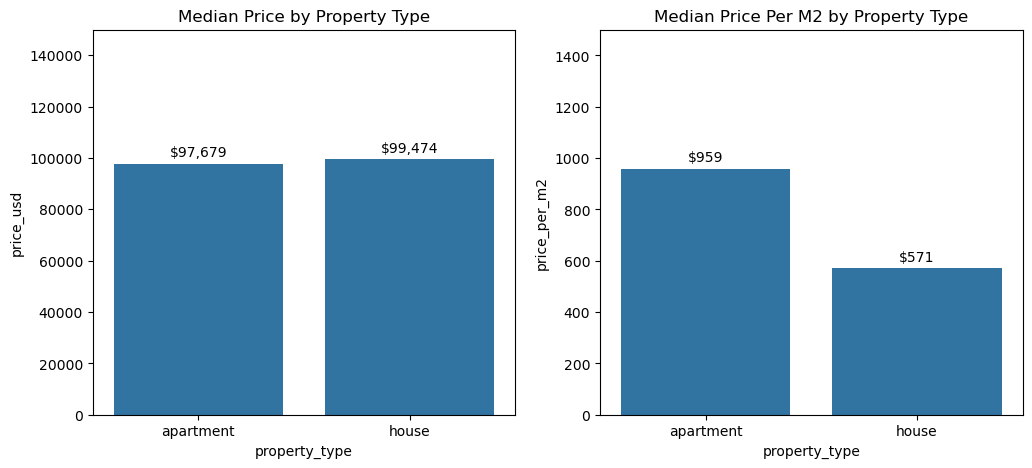

In [85]:
price_by_property_type = df.groupby('property_type')['price_usd'].median()
price_m2_by_property_type = df.groupby('property_type')['price_per_m2'].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    price_by_property_type,
    ax=ax1
)

sns.barplot(
    price_m2_by_property_type,
    ax=ax2
)

ax1.set_title('Median Price by Property Type')
ax2.set_title('Median Price Per M2 by Property Type')

ax1.set_ylim(0, 150000)
ax2.set_ylim(0, 1500)

for container in ax1.containers:
    ax1.bar_label(container, fmt='${:,.0f}', padding=3)

for container in ax2.containers:
    ax2.bar_label(container, fmt='${:,.0f}', padding=3)


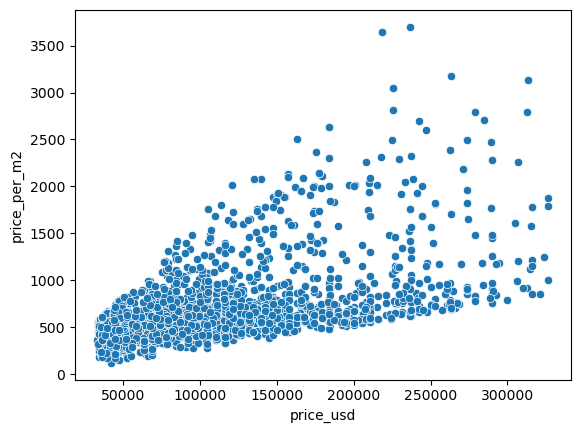

In [92]:
sns.scatterplot(
    df,
    x='price_usd',
    y='price_per_m2'
);

<Axes: >

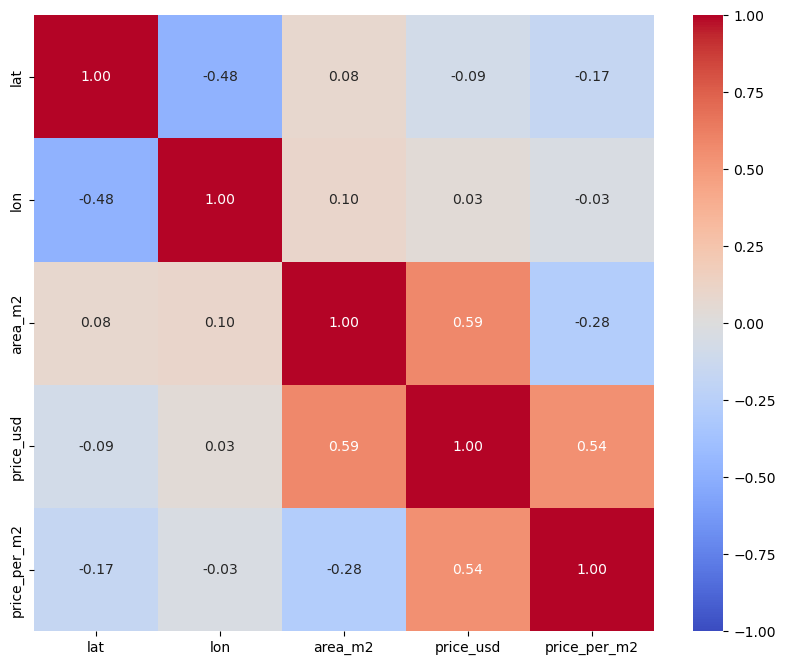

In [89]:
corr_matrix = df.corr(numeric_only=True)

# 3. Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# 4. Create the heatmap using Seaborn
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

## Key Findings & EDA Summary

* Approximately 1 in 4 properties (~25%) in the dataset is an apartment.
* `price_usd` is strongly right-skewed with a long tail of luxury listings. Based on the Interquartile Range (IQR) rule, listings above ~$275,000 are statistical outliers. A log transformation (`np.log1p`) may benefit linear models.
* There is a moderate positive correlation ($r = 0.58$) between `area_m2` and `price_usd`, confirming property size is a primary driver of overall cost.
* **Geographic Variations:**
  * **By Total Median Price:** Guanajuato, Quintana Roo, and Querétaro rank highest.
  * **By Median Price per $m^2$:** Distrito Federal (CDMX) ranks #1, followed by Guerrero and Quintana Roo.
* **Apartment vs. House Dynamics:**
  * While median overall prices between apartments and houses are comparable, apartments cost significantly more per unit area (**$959/m²** vs. **$571/m²**—a **~68% premium**).
* Price vs. Price per $m^2$ ($r = 0.54$) Demonstrates that higher-priced listings carry higher per-square-meter premiums (location/luxury effect). 

Note: `price_per_m2` must be excluded from feature sets to prevent target leakage.